# Assignment 1
## use this template!

This is the Notebook template that you would need for submitting your Assignment 1. Follow the order of this Notebook in reporting. If that is not followed, the assignment is not passed, hence resulting in 0 points.

The objective for this assignment is to build classification model to classify different types of network attacks in the CICIDS2017 dataset.
 - See Assignment 1 in Moodle for more detailed information

In general, when you get going with the assignment, it is good to note, that your codes would not (most probably) be such that you would run them on one machine and hence that your code would be just one file. Rather, right at the beginning, start planning together a skeleton for your code that serves as starting point for every group member. Then you divide among your group, which classification algorithm is handled by whom. Possibly by defining then more precisely which exact hyperparameters and pipeline steps you would utilize for that particular model. Read through this Notebook template and I believe you start to get the idea of how you could start approaching this assignment!

Below, I have provided topics which need to be answered below it. Do not change the order.

---

## 1. The Group 
- List briefly the group name, group member names and the study groups for the group members
## Group 22
- Jenna Kiviaho, Lotta Kauppinen, Marjaana Koski, Jani Laakso, Aleksi Savukoski

---

## 2. Contributions for the group members
Notice, basically everybody need to be able to do every step required. Of course, it may be that the group will work on the skeleton for the trainings together. Remember to say that if so. But if somebody is clearly not knowledgeable on, say, PCA and has not done anything with that, the group must make that clear here. In a way, that will become clear below with the results but that needs to be said here also.
- Explain the  of each group member.

| Group member name | Contibution |
| :--- | :--- |
| First Name, Last Name | Example: Did study all the steps for the pre-processing for example, was conducting the trainings and testing for kNN,<br> Was considering hyper parameter k and PCA, ran experiment w/o SMOTE also|
| Lotta Kauppinen | SVM |
| Jenna Kiviaho | Logistic Regression |
| Aleksi Savukoski | kNN |
|  | Decision Tree |
|  | Random Forest |
|  | Naive Bayes |




---

---

## 3. Use of AI
- Explain, how did you utilize AI to help you with the assignment?
- Each member does reporting they status individually

| Group member name | Contibution |
| :--- | :--- |
| First Name, Last Name | Example: I did not use AI at all|
| Aleksi Savukoski |Claude helps with code and explains step by step how and why the code works. I suck at coding so Claude is useful |
|  |  |
|  |  |
|  |  |
|  |  |

---

## 4. Dataset, Splitting the dataset
- How is the data sampled for the training, validation and testing dataset?

- How did you make sure everyone is using the same data?



In [4]:
# all libraries here

import numpy as np
import pandas as pd
import sklearn
import imblearn
import xgboost
import matplotlib
import seaborn
from sklearn.model_selection import train_test_split

---

In [5]:
df_original = pd.read_csv("data/cicids2017_cleaned.csv", low_memory=False) #AS : remember to put the csv file in the right folder (data/)
df_100 = df_original.sample(n=100_000, random_state=42)

In [6]:
#### 20.4. MK: this was only to compare the sample dataset to the original one

counts_original = df_original["Attack Type"].value_counts()
percentages_original = df_original["Attack Type"].value_counts(normalize=True)

counts_100 = df_100["Attack Type"].value_counts()
percentages_100 = df_100["Attack Type"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "Row count original" : counts_original, 
    "Count-% original": percentages_original.round(5)*100,
    "Row count sample file" : counts_100, 
    "Count-% sample file": percentages_100.round(5)*100})

print(comparison)

                Row count original  Count-% original  Row count sample file  \
Attack Type                                                                   
Normal Traffic             2095057            83.112                  83081   
DoS                         193745             7.686                   7673   
DDoS                        128014             5.078                   5115   
Port Scanning                90694             3.598                   3574   
Brute Force                   9150             0.363                    377   
Web Attacks                   2143             0.085                     92   
Bots                          1948             0.077                     88   

                Count-% sample file  
Attack Type                          
Normal Traffic               83.081  
DoS                           7.673  
DDoS                          5.115  
Port Scanning                 3.574  
Brute Force                   0.377  
Web Attacks           

In [7]:
df_100.to_csv("cleaned_100k.csv", index=False)

In [8]:
# The dataset and dataframe to be used

df = pd.read_csv("cleaned_100k.csv", low_memory=False)

The original dataset contained over 2.3 million rows. The original CSV file was sampled with Pandas to 100 000 items with random state of 42. If the original dataframe based on cicids2017_cleaned.csv would be read in, with random state = 42 the sample dataframe would be exactly the same.

 In dataset cicids2017_cleaned.csv there are 7 unique attack types, it is a paramount to have each type represented in the sample file. This way only the train-test model can learn about more rare attack type classes. For performance and computational purposes, randomly chosen 100 000 rows from the original set were chosen.

The comparison between original dataset and sample file is represented in this table:
| Attack Type     | Row Count (Original) | Percent % (Original) | Row Count (Sample) | Percent % (Sample) |
|-----------------|-----------------------|------------------------|---------------------|----------------------|
| Normal Traffic  | 2 095 057             | 83.112                 | 83 081              | 83.081               |
| DoS             |   193 745             | 7.686                  | 7 673               | 7.673                |
| DDoS            |   128 014             | 5.078                  | 5 115               | 5.115                |
| Port Scanning   |    90 694             | 3.598                  | 3 574               | 3.574                |
| Brute Force     |     9 150             | 0.363                  |   377               | 0.377                |
| Web Attacks     |     2 143             | 0.085                  |    92               | 0.092                |
| Bots            |     1 948             | 0.077                  |    88               | 0.088                |

The percentages of each attack type are well represented in the dataset, as it mimics the original dataset's propotions.

The dataframe was exported into CSV file named cleaned_100k.csv. This CSV is also used as a basis for the assignment's dataframe, which confirms, that the assignment is based solely on the sampled dataset and dataframe.

In [9]:
# Defining target
y = df['Attack Type']
X = df.drop('Attack Type', axis = 1)

# First to split data into train and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Split train again into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify = y_train_val)


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(60000, 52)
(20000, 52)
(20000, 52)


---

### Shared skeleton for the group # 23.4. AS

The cell below is a **shared skeleton** every group member uses as the starting point for their own classifier. It locks down the decisions that must be identical across the team so results are comparable in Section 10:

- the same 10 features (`FEATURES`),
- the same pipeline order (Scaler → PCA → SMOTE → Classifier),
- the same scoring metric for GridSearchCV (`f1_macro`, because accuracy is misleading under 83% class imbalance),
- the same `run_experiment()` helper so every algorithm is evaluated the same way and logged into `all_results`.

Each member only fills in their classifier and its `param_grid`; an example for kNN is shown at the bottom of the cell (commented out).

Note: SMOTE is wrapped by **imblearn's** Pipeline, not sklearn's, so synthetic samples are only generated inside each CV training fold, never inside the fold used for scoring. Using sklearn's Pipeline here would silently inflate scores.

In [10]:
# =====================================================================
#  SHARED SKELETON - all group members use this as the starting point.
#  Only the classifier in 'clf' and the 'param_grid' change per algorithm.
# =====================================================================

# Extra imports beyond the ones in the top imports cell
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import matplotlib.pyplot as plt


#1. 10-feature list (# 23.4. AS: Suggested features)
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
# All feature names really exist in the dataframe
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"


#2. Subset each split to just those features
X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]


#3. Shared grid-search settings
# f1_macro treats every class equally, so Bots counts as much as
# Normal Traffic. Accuracy would be misleading under 83% imbalance.
CV_FOLDS = 5
SCORING  = "f1_macro"
N_JOBS   = -1   # -1 = use all CPU cores


#4. Shared helper every member calls
def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
    """
    Fit a Pipeline + GridSearchCV for one classifier and return a results dict.

    Parameters
    ----------
    clf        : an sklearn classifier instance, e.g. KNeighborsClassifier()
    param_grid : dict of hyperparameters to search. Use the double-underscore
                 naming: 'clf__n_neighbors', 'pca__n_components', etc.
    label      : human-readable name for this run (appears in plot + prints)
    use_smote  : set False to run the no-SMOTE baseline
    use_pca    : set False to skip PCA (replaced with 'passthrough')
    """
    # Build pipeline for this run. 'passthrough' means "do nothing at this step"
    # and lets us turn SMOTE or PCA on/off without changing the pipeline shape.
    steps = [("scaler", StandardScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1,
    )

    # Fit on TRAIN only. GridSearchCV does its own 5-fold CV internally.
    grid.fit(X_train_sel, y_train)

    # Evaluate on VALIDATION (independent second check)
    y_val_pred = grid.predict(X_val_sel)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1  = f1_score(y_val, y_val_pred, average="macro")

    # Evaluate on TEST. IMPORTANT: only look at this ONCE at the very end!
    y_test_pred = grid.predict(X_test_sel)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    # Confusion matrix on the test set
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} - test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }


#5. Shared results container (every member appends to this)
all_results = []


# =====================================================================
#  PER-MEMBER USAGE EXAMPLE (kNN - commented out)
#  Copy this block, swap in your own classifier + param_grid.
# =====================================================================
# from sklearn.neighbors import KNeighborsClassifier
#
# knn_grid = {
#     "pca__n_components": [4, 6, 8],
#     "clf__n_neighbors":  [3, 5, 7, 11],
#     "clf__weights":      ["uniform", "distance"],
# }
#
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN + SMOTE + PCA")
# )
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN no-SMOTE baseline", use_smote=False)
# )

Fitting 5 folds for each of 24 candidates, totalling 120 fits


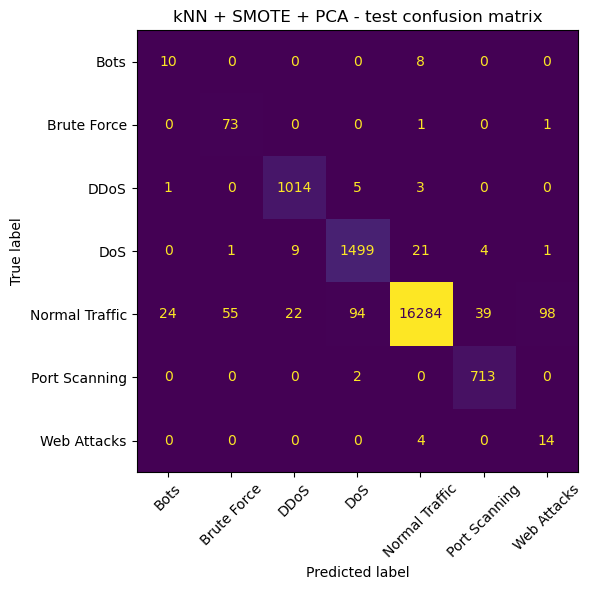


=== kNN + SMOTE + PCA ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9801  f1_macro=0.7569
Test acc=0.9804  f1_macro=0.7429
                precision    recall  f1-score   support

          Bots      0.286     0.556     0.377        18
   Brute Force      0.566     0.973     0.716        75
          DDoS      0.970     0.991     0.981      1023
           DoS      0.937     0.977     0.956      1535
Normal Traffic      0.998     0.980     0.989     16616
 Port Scanning      0.943     0.997     0.969       715
   Web Attacks      0.123     0.778     0.212        18

      accuracy                          0.980     20000
     macro avg      0.689     0.893     0.743     20000
  weighted avg      0.987     0.980     0.983     20000



In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid = {
    "pca__n_components": [4, 6, 8],
    "clf__n_neighbors":  [3, 5, 7, 11],
    "clf__weights":      ["uniform", "distance"],
}

all_results.append(
    run_experiment(KNeighborsClassifier(), knn_grid,
                   label="kNN + SMOTE + PCA")
)

## 5. Label variable

This is a **multi-class classification** problem with 7 classes in the `Attack Type` column:

| Class | Share of data |
| :--- | ---: |
| Normal Traffic | 83.08% |
| DoS | 7.67% |
| DDoS | 5.12% |
| Port Scanning | 3.57% |
| Brute Force | 0.38% |
| Web Attacks | 0.09% |
| Bots | 0.09% |

The dataset is **severely imbalanced** — Normal Traffic outnumbers Bots by roughly 1000:1. Because of this, we report **`f1_macro`** as our primary metric rather than raw accuracy. Accuracy is misleading here: a model that predicts "Normal Traffic" for every single row would still score ~83% accuracy while completely failing at its actual job (detecting attacks). `f1_macro` averages the F1-score across all 7 classes equally, so a model has to do well on the rare attack types to earn a good score.

For the same reason we apply **SMOTE** inside the training pipeline to synthetically oversample the minority classes during fitting (§7), and we use **`stratify=y`** when splitting so that every class is present in the train, validation, and test sets in the same proportions.

---

23.4. AS: Suggested features
## 6. Feature variables

The cleaned dataset contains 52 numeric feature columns. Rather than feed all of them to every model, the group agreed on a common set of **10 flow-level features** chosen to cover the main information axes a network-traffic classifier needs. Using the same 10 features across all 7 algorithms also makes the comparison in §10 meaningful — any performance differences come from the classifier, not from different feature sets.

**The 10 "agreed" features:**

| Feature | What it captures |
| :--- | :--- |
| Flow Duration | How long the connection lasted |
| Total Fwd Packets | Packet count in the forward direction (volume) |
| Total Length of Fwd Packets | Total bytes in the forward direction (volume) |
| Flow Bytes/s | Byte rate — high for DDoS, low for Port Scanning |
| Flow Packets/s | Packet rate — separates scanning from bulk traffic |
| Fwd Packet Length Mean | Average size of forward packets |
| Bwd Packet Length Mean | Average size of backward packets — asymmetry is a strong attack signal |
| Packet Length Mean | Overall packet size average |
| Packet Length Std | Variability in packet size — uniform sizes suggest automated/attack traffic |
| Average Packet Size | Summary size statistic |

**Reasoning behind the selection:**

1. **Coverage of five information axes.** Network attacks differ along *timing* (Flow Duration), *volume* (packet and byte totals), *rate* (bytes/s, packets/s), *packet size distribution* (means and std), and *directional asymmetry* (forward vs backward statistics). Each axis is represented.
2. **Forward + backward directions.** Many attacks are highly asymmetric — Port Scanning sends lots of small SYN packets forward and receives little back; DoS floods one direction. Keeping both `Fwd` and `Bwd` statistics preserves this signal.
3. **Ratios and rates, not just counts.** Absolute counts depend on how long the flow ran. `Flow Bytes/s` and `Flow Packets/s` are normalized and comparable across flow durations.
4. **Avoid redundant/derived columns.** The full dataset contains many near-duplicate or derived columns (subflow totals, init window sizes for each direction, etc.). Picking a compact set reduces multicollinearity, speeds up training, and — importantly for kNN — mitigates the curse of dimensionality.
5. **Algorithm-neutral features.** All 10 are continuous numeric columns that work directly with scaling, PCA, and SMOTE without special encoding.


---

## 7. SMOTE
- Explain shortly how SMOTE took place in your tests. Report your overall findings for SMOTE already here even though you may or may not say something on SMOTE later in the Results section. I say this like this because, the results section may become populated with lots of results already otherwise, so this might be your opportunity to keep that section simpler.


---

## 8. Scaling, Polyfeatures, PCA, LDA, Kernel PCA


- Similar to SMOTE above. You will most probably run lots of tests on your own separate Notebooks different from this group level submission Notebook.
- Again, the results section may become populated with lots of results already otherwise, so this might be your opportunity to keep that section simpler.
- Still say conclusions shortly, what worked, what not
- Paste here a code sample/snippet showing the main steps, their tested orders and settings you used for these. Yes, the code snipped may not be functional on this notebook, as this is supposed to be just snippet illustrating your working. Adding all, would probably make the document messy!
- So explain main effect these step had for your trainings. Did something work or not, so basically when did you got benefit from those.
- Which parameters did provide the best results in case of which algorithm


---

## 9. Training setups
- Provide snippets of code that would through Pipeline and GripSearchCV variables make it clear which hyperparameters did you cover, what where the order of steps for standardization, feature dimensionality reduction etc. Ok, maybe bit overlapping with the part 8. above but at least the classification algorithms were not covered there. 
- I wrote snippets(!) in plural form as for different members of the group, you may have needed to make adjustments to those variables depending on, for example, the classification algorithm that you personally have been working with.
- However, do not exaggerate. Keep the snippets concise and short, the point is to show and convince me that you have done what you were supposed to and you know what you were doing
- As mentioned at the end of the Assignment 1 description in Moodle, in addition to this Notebook, zip your personal working Notebooks were you show more functional code. However, I check these only if needed for some reason. So basically, the idea is to write here things so that I would not need to check those. So it is about the clarity of the submission in a way.
 

---

## 10. Classification Results and Best model/models
- Again, make sure you use same data for training, validation and testing.
- Collect your results then together here
- Provide accuracies and confusion matrices. Maybe selfevident, but the results need to be comparable for different algorithms. So present them that way also.
- You can also consider precision, recall and F1-score. At least Recall may be interresting to observe when comparing the performance with or without SMOTE
- What is then the best model/models, point that out
- What is then the setup (preprocessing steps, hyperparameter) that produced that best model(s)?


---

Finally, make sure for the last time that this documentation of yours would make sense for somebody who might continue your work with extended data later on.
